[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lifeng6666666/freeLearnLab/blob/main/macheine-learning/ch03.ipynb)


# 第 3 章 · 决策树

从零用 **CART + 基尼系数** 递归建树实现 `MyDecisionTreeClassifier`，与 sklearn `DecisionTreeClassifier` 对比，最后应用到贷款审批场景。

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 中文字体配置（仅在此cell设置一次，后续cell直接使用plt即可）
import os, platform
if platform.system() == 'Linux' and os.path.exists('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

COLORS = {
    'primary': '#6b6144', 'accent': '#96781b', 'accent2': '#459ebb',
    'pos': '#c0392b', 'neg': '#2980b9', 'green': '#3d8e58', 'muted': '#88867f'
}

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 3.1 算法原理

决策树递归选择使【不纯度下降最多】的 (特征, 阈值) 划分。基尼系数：

$$Gini(D)=1-\sum_k p_k^2$$

在阈值 $t$ 处划分后基尼：

$$Gini_t(D)=\frac{|D_L|}{|D|}Gini(D_L)+\frac{|D_R|}{|D|}Gini(D_R)$$

信息增益 $Gain = Gini(D)-Gini_t(D)$，取最大者递归建树，直到深度/纯度达到停止条件。

> PDF 伪代码步骤：① 停止条件 ② 遍历 (a) 分割 (b) 基尼 (c) 选最优 ③ 递归建树。

## 3.2 从零实现 (核心)

代码注释中的步骤编号与 PDF 伪代码一一对应。

In [8]:
class TreeNode:
    """决策树内部节点。"""
    def __init__(self):
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None
        self.label = None
        self.is_leaf = False


class MyDecisionTreeClassifier:
    """从零实现的决策树 (CART, 基尼系数)。接口与 sklearn 一致。"""
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def _gini(self, y):
        if len(y) == 0:
            return 0.0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1.0 - np.sum(probs ** 2)

    def _majority(self, y):
        vals, counts = np.unique(y, return_counts=True)
        return vals[counts.argmax()]

    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        parent_gini = self._gini(y)
        best_gain = -1.0
        best_feat = None
        best_thr = None
        # 步骤2: 遍历特征j和阈值t
        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for thr in thresholds:
                # 步骤2(a): 按阈值分割 左集/右集
                left_mask = X[:, feature] <= thr
                right_mask = ~left_mask
                n_left, n_right = int(left_mask.sum()), int(right_mask.sum())
                if n_left == 0 or n_right == 0:
                    continue
                # 步骤2(b): 计算分裂后基尼系数 G
                gini = (n_left / n_samples) * self._gini(y[left_mask]) \
                       + (n_right / n_samples) * self._gini(y[right_mask])
                gain = parent_gini - gini
                # 步骤2(c): 选取使G最小的 (j*, t*)
                if gain > best_gain:
                    best_gain = gain
                    best_feat = feature
                    best_thr = thr
        return best_feat, best_thr, best_gain

    def _build(self, X, y, depth):
        node = TreeNode()
        # 步骤1: 检查停止条件（纯度/深度/样本数）
        if (depth >= self.max_depth or len(y) < self.min_samples_split
                or len(np.unique(y)) == 1):
            node.is_leaf = True
            node.label = self._majority(y)
            return node
        feat, thr, gain = self._best_split(X, y)
        if feat is None or gain <= 0:
            node.is_leaf = True
            node.label = self._majority(y)
            return node
        # 步骤3: 创建节点，递归建左右子树
        node.feature = feat
        node.threshold = thr
        left_mask = X[:, feat] <= thr
        node.left = self._build(X[left_mask], y[left_mask], depth + 1)
        node.right = self._build(X[~left_mask], y[~left_mask], depth + 1)
        return node

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.root = self._build(X, y, 0)
        return self

    def _predict_one(self, x):
        node = self.root
        while not node.is_leaf:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.label

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x) for x in X])


## 3.3 简单数据验证 + 决策边界

用 `make_moons` 月牙数据，对比自定义树与 sklearn 的划分边界。

自定义  acc=0.9333
sklearn  acc=0.9556


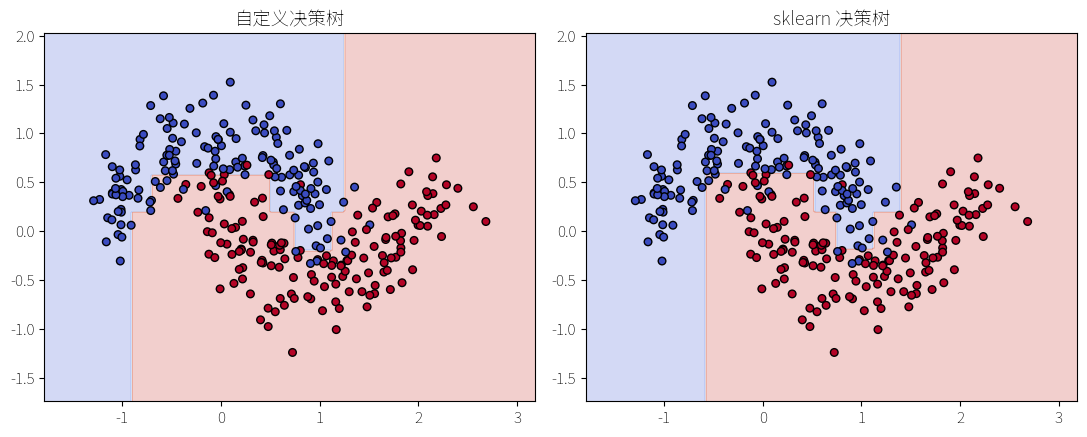

In [9]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.25, random_state=7)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=7)

my_tree = MyDecisionTreeClassifier(max_depth=5).fit(X_tr, y_tr)
sk_tree = DecisionTreeClassifier(max_depth=5, random_state=7).fit(X_tr, y_tr)
print('自定义  acc=%.4f' % accuracy_score(y_te, my_tree.predict(X_te)))
print('sklearn  acc=%.4f' % accuracy_score(y_te, sk_tree.predict(X_te)))

def plot_db(model, X, y, ax, title):
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min,x_max,200), np.linspace(y_min,y_max,200))
    Z = np.asarray(model.predict(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm)
    ax.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm, edgecolor='k', s=30)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
plot_db(my_tree, X, y, axes[0], '自定义决策树')
plot_db(sk_tree, X, y, axes[1], 'sklearn 决策树')
plt.tight_layout(); plt.show()


## 3.4 与 sklearn 对比 (乳腺癌数据)

在真实高维数据上量化对比准确率与混淆矩阵。

自定义  acc=0.9181
sklearn  acc=0.9181


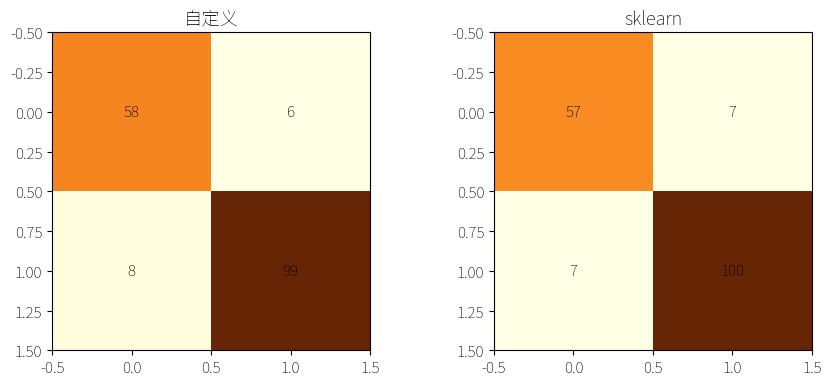

In [10]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X_tr, X_te, y_tr, y_te = train_test_split(data.data, data.target, test_size=0.3,
                                          random_state=42, stratify=data.target)
my_tree = MyDecisionTreeClassifier(max_depth=6).fit(X_tr, y_tr)
sk_tree = DecisionTreeClassifier(max_depth=6, random_state=42).fit(X_tr, y_tr)
my_p = my_tree.predict(X_te); sk_p = sk_tree.predict(X_te)
print('自定义  acc=%.4f' % accuracy_score(y_te, my_p))
print('sklearn  acc=%.4f' % accuracy_score(y_te, sk_p))

fig, axes = plt.subplots(1, 2, figsize=(9,4))
for ax, (p, t) in zip(axes, [(my_p,'自定义'),(sk_p,'sklearn')]):
    cm = confusion_matrix(y_te, p)
    im = ax.imshow(cm, cmap='YlOrBr')
    ax.set_title(t)
    for i in range(2):
        for j in range(2):
            ax.text(j,i,cm[i,j],ha='center',va='center')
plt.tight_layout(); plt.show()


## 3.5 真实应用 · 贷款审批

构造贷款审批场景：根据收入、信用分、贷款额、年龄、在职年限判断是否批准。
(用合成数据，规则可解释，便于看树如何切分。)

特征: `income / credit_score / loan_amount / age / years_employed`，标签 0=拒 1=批。

In [11]:
rng = np.random.RandomState(123)
n = 1200
income = rng.normal(60, 25, n).clip(10, 200)
credit_score = rng.normal(650, 80, n).clip(300, 850)
loan_amount = rng.normal(30, 20, n).clip(1, 150)
age = rng.normal(38, 10, n).clip(20, 70)
years_employed = rng.normal(6, 5, n).clip(0, 30)
X = np.column_stack([income, credit_score, loan_amount, age, years_employed])
approve = ((credit_score > 620) & (income / loan_amount > 2.5)).astype(int)
flip = rng.rand(n) < 0.05
approve[flip] = 1 - approve[flip]
y = approve

cols = ['收入','信用分','贷款额','年龄','在职年']
df = pd.DataFrame(X, columns=cols); df['批准'] = y
print(df.head())
print('\\n批准率:', y.mean().round(3))

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=7, stratify=y)
my_tree = MyDecisionTreeClassifier(max_depth=5).fit(X_tr, y_tr)
sk_tree = DecisionTreeClassifier(max_depth=5, random_state=7).fit(X_tr, y_tr)
print('自定义  acc=%.4f' % accuracy_score(y_te, my_tree.predict(X_te)))
print('sklearn  acc=%.4f' % accuracy_score(y_te, sk_tree.predict(X_te)))
print(classification_report(y_te, my_tree.predict(X_te), target_names=['拒绝','批准']))


          收入         信用分        贷款额         年龄       在职年  批准
0  32.859235  738.936140  10.890573  34.325810  6.788747   1
1  84.933636  664.476572  41.070077  43.752726  9.756878   0
2  67.074462  756.624075  63.797591  42.393508  4.306340   0
3  22.342632  729.114025  24.752029  30.718478  0.000000   0
4  45.534994  600.642358  13.951079  29.114704  6.772980   0
\n批准率: 0.294
自定义  acc=0.9067
sklearn  acc=0.8967
              precision    recall  f1-score   support

          拒绝       0.93      0.94      0.93       212
          批准       0.85      0.83      0.84        88

    accuracy                           0.91       300
   macro avg       0.89      0.88      0.89       300
weighted avg       0.91      0.91      0.91       300



## 3.6 小结

- 决策树通过递归二分把特征空间切成矩形区域，可解释性强；
- 自定义 CART 与 sklearn 在同一深度下准确率非常接近；
- 单树易过拟合，下一章集成学习用多棵树缓解。